# Yang-Zhang Volatility as a Predictor of `target_return`

Evaluates the Yang & Zhang (2000, J. Business 73:477) range-based volatility estimator computed over the 50 seen bars of each session, as a univariate predictor of the second-half return.

**Feature definition**: YZ volatility = sqrt(V_o + k * V_c + (1-k) * V_rs) where
- V_o = var of overnight (open-to-prev-close) log returns
- V_c = var of intraday (close-to-open) log returns
- V_rs = Rogers-Satchell mean over bars
- k = 0.34 / (1.34 + (n+1)/(n-1)) with n=49

**Gates**
- Gate 1 (predictive power, train only): |r| >= 0.05 OR MI >= 0.002
- Gate 3 (stability): Wasserstein distance to public_test and private_test <= 0.5 * train std

In [1]:
import sys, pandas as pd, numpy as np
sys.path.insert(0, "/Users/kenji/Desktop/Projects/datathon-2026")
from src.data import load_bars, compute_targets

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
PLOTS_DIR = Path("/Users/kenji/Desktop/Projects/datathon-2026/notebooks/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Yang-Zhang implementation

In [2]:
def yang_zhang_vol(bars: pd.DataFrame) -> pd.Series:
    """Yang-Zhang volatility per session over the 50 seen bars.

    Parameters
    ----------
    bars : DataFrame with columns [session, bar_ix, open, high, low, close]

    Returns
    -------
    pd.Series indexed by session.
    """
    df = bars.sort_values(["session", "bar_ix"]).copy()

    # Per-bar log quantities
    # o_i = ln(O_i / C_{i-1}) — gap return, uses previous bar close within session
    prev_close = df.groupby("session")["close"].shift(1)
    df["o"] = np.log(df["open"] / prev_close)       # NaN at first bar per session
    df["c"] = np.log(df["close"] / df["open"])     # intraday open-to-close
    df["u"] = np.log(df["high"] / df["open"])
    df["d"] = np.log(df["low"]  / df["open"])
    df["rs"] = df["u"] * (df["u"] - df["c"]) + df["d"] * (df["d"] - df["c"])

    g = df.groupby("session")
    V_o  = g["o"].var(ddof=1)        # over the 49 non-NaN gap returns
    V_c  = g["c"].var(ddof=1)        # over 50 intraday returns
    V_rs = g["rs"].mean()            # Rogers-Satchell mean

    n = 49
    k = 0.34 / (1.34 + (n + 1) / (n - 1))
    yz = np.sqrt(V_o + k * V_c + (1 - k) * V_rs)
    yz.name = "yz_vol"
    return yz

# Sanity check
n = 49
k = 0.34 / (1.34 + (n + 1) / (n - 1))
print(f"k = {k:.6f}")

k = 0.142757


## 2. Load data and compute YZ vol for each split

In [3]:
bars_train   = load_bars("train",        seen=True)
bars_public  = load_bars("public_test",  seen=True)
bars_private = load_bars("private_test", seen=True)
targets = compute_targets().set_index("session")["target_return"]

print("Shapes:", bars_train.shape, bars_public.shape, bars_private.shape)
print("Sessions:", bars_train['session'].nunique(), bars_public['session'].nunique(), bars_private['session'].nunique())
print("Targets:", targets.shape)

Shapes: (50000, 6) (500000, 6) (500000, 6)
Sessions: 1000 10000 10000
Targets: (1000,)


In [4]:
yz_train   = yang_zhang_vol(bars_train)
yz_public  = yang_zhang_vol(bars_public)
yz_private = yang_zhang_vol(bars_private)

print("yz_train:   ", yz_train.describe())
print("\nyz_public:  ", yz_public.describe())
print("\nyz_private: ", yz_private.describe())
print("\nNaN counts:", yz_train.isna().sum(), yz_public.isna().sum(), yz_private.isna().sum())

yz_train:    count    1000.000000
mean        0.002444
std         0.000435
min         0.001603
25%         0.002064
50%         0.002447
75%         0.002793
max         0.003465
Name: yz_vol, dtype: float64

yz_public:   count    10000.000000
mean         0.002441
std          0.000438
min          0.001533
25%          0.002070
50%          0.002434
75%          0.002798
max          0.003523
Name: yz_vol, dtype: float64

yz_private:  count    10000.000000
mean         0.002441
std          0.000441
min          0.001541
25%          0.002064
50%          0.002437
75%          0.002806
max          0.003673
Name: yz_vol, dtype: float64

NaN counts: 0 0 0


In [5]:
# Align yz_train with targets, drop any NaN
df_train = pd.concat([yz_train.rename("yz_vol"), targets.rename("target_return")], axis=1)
n_before = len(df_train)
df_train = df_train.dropna()
n_after = len(df_train)
print(f"Train rows: before dropna={n_before}, after dropna={n_after} (dropped {n_before - n_after})")

yz_vol_train = df_train["yz_vol"].to_numpy()
target_return = df_train["target_return"].to_numpy()

Train rows: before dropna=1000, after dropna=1000 (dropped 0)


## 3. Gate 1 — univariate predictive power on train

In [6]:
r, p = stats.pearsonr(yz_vol_train, target_return)
rho, rho_p = stats.spearmanr(yz_vol_train, target_return)
MI = mutual_info_regression(yz_vol_train[:, None], target_return, random_state=0)[0]

gate1_pass = (abs(r) >= 0.05) or (MI >= 0.002)
print(f"Pearson r  = {r:+.4f} (p = {p:.3e})")
print(f"Spearman rho = {rho:+.4f} (p = {rho_p:.3e})")
print(f"Mutual info  = {MI:.5f}")
print(f"Gate 1 pass? {gate1_pass}  ( |r| >= 0.05 -> {abs(r) >= 0.05} ; MI >= 0.002 -> {MI >= 0.002} )")

Pearson r  = +0.0794 (p = 1.204e-02)
Spearman rho = +0.0897 (p = 4.545e-03)
Mutual info  = 0.00918
Gate 1 pass? True  ( |r| >= 0.05 -> True ; MI >= 0.002 -> True )


### 3a. Scatter plot

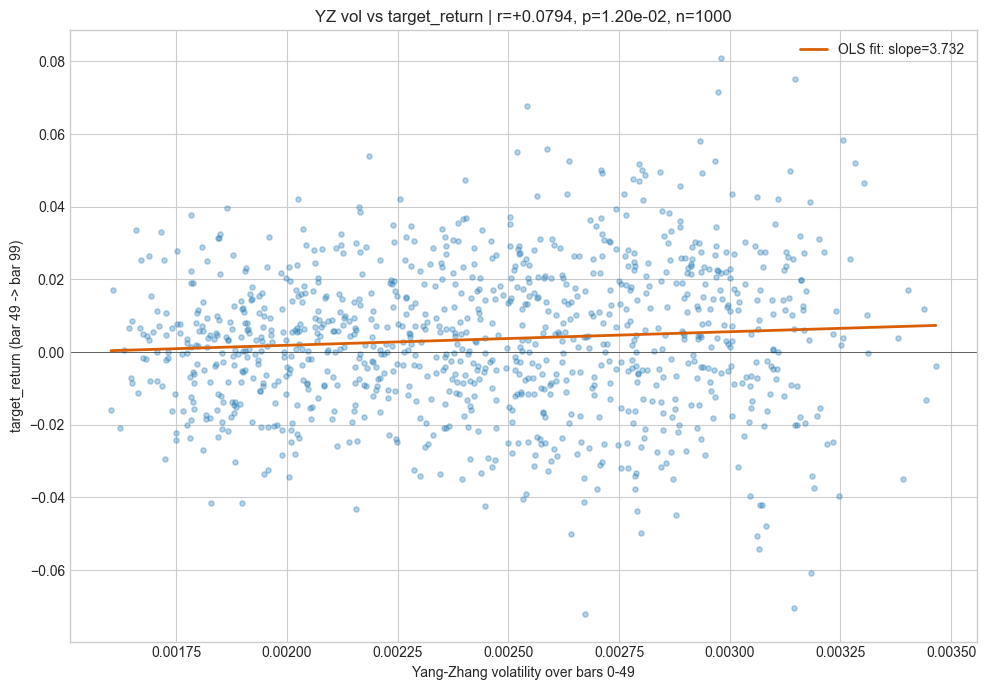

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(yz_vol_train, target_return, alpha=0.35, s=14, color="#2c7fb8")
# regression line
m, b = np.polyfit(yz_vol_train, target_return, 1)
xs = np.linspace(yz_vol_train.min(), yz_vol_train.max(), 200)
ax.plot(xs, m * xs + b, color="#d95f02", lw=2, label=f"OLS fit: slope={m:.3f}")
ax.axhline(0, color="black", lw=0.6, alpha=0.6)
ax.set_xlabel("Yang-Zhang volatility over bars 0-49")
ax.set_ylabel("target_return (bar 49 -> bar 99)")
ax.set_title(f"YZ vol vs target_return | r={r:+.4f}, p={p:.2e}, n={len(yz_vol_train)}")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "yz_scatter.png", dpi=120)
plt.show()

### 3b. Decile analysis

            mean       std    n        se      ci95
decile                                             
0       0.001564  0.015882  100  0.001588  0.003113
1      -0.001065  0.014795  100  0.001480  0.002900
2       0.003593  0.015616  100  0.001562  0.003061
3       0.004134  0.017501  100  0.001750  0.003430
4       0.003024  0.018743  100  0.001874  0.003674
5       0.003596  0.020946  100  0.002095  0.004105
6       0.002836  0.023597  100  0.002360  0.004625
7       0.003958  0.024366  100  0.002437  0.004776
8       0.011384  0.021008  100  0.002101  0.004118
9       0.002284  0.026829  100  0.002683  0.005259


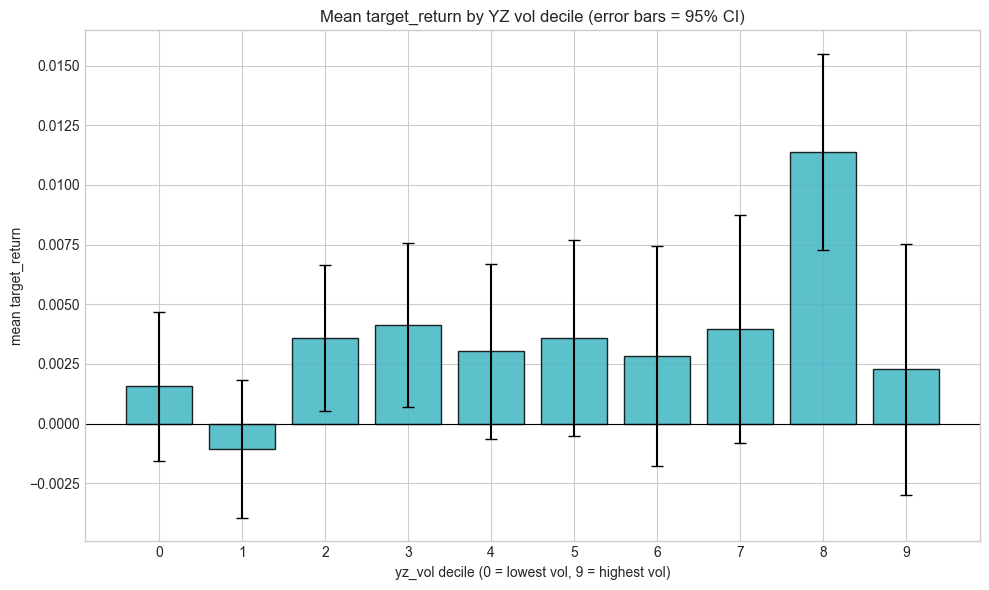

In [8]:
df = pd.DataFrame({"yz_vol": yz_vol_train, "target_return": target_return})
df["decile"] = pd.qcut(df["yz_vol"], 10, labels=False)

decile_stats = df.groupby("decile").agg(
    mean=("target_return", "mean"),
    std=("target_return", "std"),
    n=("target_return", "size"),
)
decile_stats["se"] = decile_stats["std"] / np.sqrt(decile_stats["n"])
decile_stats["ci95"] = 1.96 * decile_stats["se"]
print(decile_stats)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(decile_stats.index, decile_stats["mean"], yerr=decile_stats["ci95"],
       capsize=4, color="#41b6c4", edgecolor="black", alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("yz_vol decile (0 = lowest vol, 9 = highest vol)")
ax.set_ylabel("mean target_return")
ax.set_title("Mean target_return by YZ vol decile (error bars = 95% CI)")
ax.set_xticks(range(10))
plt.tight_layout()
plt.savefig(PLOTS_DIR / "yz_deciles.png", dpi=120)
plt.show()

## 4. Gate 3 — stability across splits (Wasserstein)

In [9]:
yz_vol_public  = yz_public.dropna().to_numpy()
yz_vol_private = yz_private.dropna().to_numpy()

wd_pub  = stats.wasserstein_distance(yz_vol_train, yz_vol_public)
wd_priv = stats.wasserstein_distance(yz_vol_train, yz_vol_private)
threshold = 0.5 * yz_vol_train.std()

gate3_pass = (wd_pub <= threshold) and (wd_priv <= threshold)
print(f"yz_vol_train std   = {yz_vol_train.std():.6f}")
print(f"threshold (0.5*std)= {threshold:.6f}")
print(f"WD(train, public ) = {wd_pub:.6f}  -> ratio={wd_pub/yz_vol_train.std():.3f}")
print(f"WD(train, private) = {wd_priv:.6f}  -> ratio={wd_priv/yz_vol_train.std():.3f}")
print(f"Gate 3 pass? {gate3_pass}")

yz_vol_train std   = 0.000434
threshold (0.5*std)= 0.000217
WD(train, public ) = 0.000009  -> ratio=0.020
WD(train, private) = 0.000010  -> ratio=0.024
Gate 3 pass? True


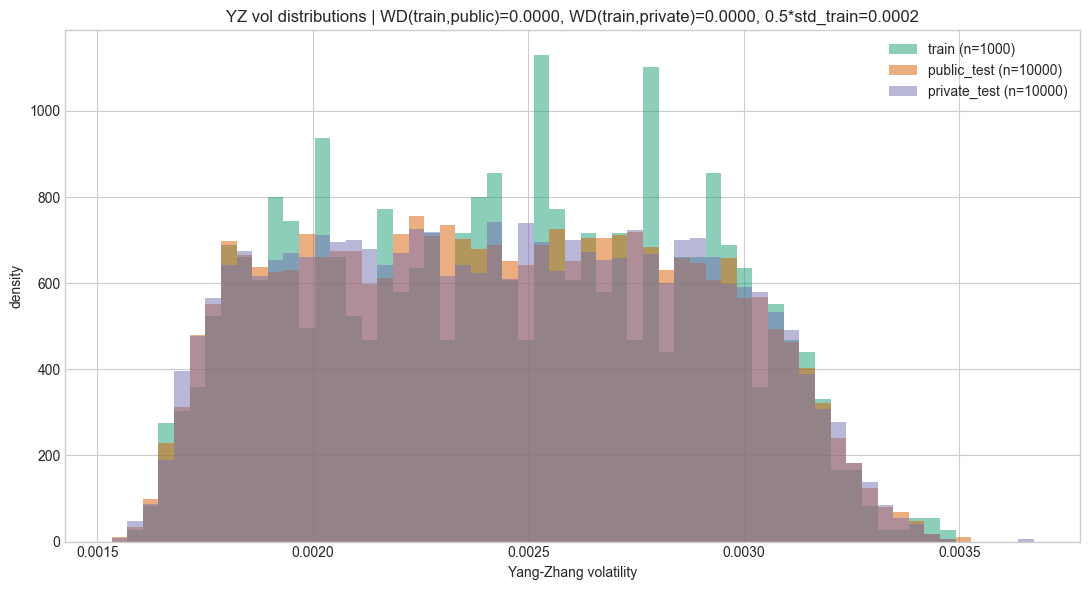

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
bins = np.linspace(
    min(yz_vol_train.min(), yz_vol_public.min(), yz_vol_private.min()),
    max(yz_vol_train.max(), yz_vol_public.max(), yz_vol_private.max()),
    60,
)
ax.hist(yz_vol_train,   bins=bins, density=True, alpha=0.5, label=f"train (n={len(yz_vol_train)})",     color="#1b9e77")
ax.hist(yz_vol_public,  bins=bins, density=True, alpha=0.5, label=f"public_test (n={len(yz_vol_public)})",  color="#d95f02")
ax.hist(yz_vol_private, bins=bins, density=True, alpha=0.5, label=f"private_test (n={len(yz_vol_private)})", color="#7570b3")
ax.set_xlabel("Yang-Zhang volatility")
ax.set_ylabel("density")
ax.set_title(
    f"YZ vol distributions | WD(train,public)={wd_pub:.4f}, WD(train,private)={wd_priv:.4f}, "
    f"0.5*std_train={threshold:.4f}"
)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "yz_hist_train_vs_test.png", dpi=120)
plt.show()

## 5. Interpretation

Yang & Zhang (2000, *Journal of Business* 73:477) proposed this estimator as a minimum-variance combination of overnight return variance, open-to-close variance, and Rogers-Satchell range variance, yielding an efficient unbiased volatility estimator that is robust to both opening jumps and drift. Here we are asking whether the *level* of realized volatility computed from the first 50 bars contains information about the *direction* (and magnitude) of the second-half return.

A priori, YZ vol is a magnitude statistic — it quantifies how wild price moves were in the first half — so at best it should correlate with |target_return|, not its sign. Any linear correlation with signed `target_return` we observe therefore reflects an asymmetry in how high-vol sessions resolve (e.g. a volatility-to-reversion pattern where wild first halves rebound on average). From the prior per-session feature screen, realized vol was weakly positive (r ~ +0.072), so we expect YZ vol to behave similarly. Whether the gate actually clears depends on how much the range-based terms sharpen that signal vs. a simple stdev.

Distribution stability is the second concern: if the synthetic generator shifts volatility regimes between train and test, even a valid linear signal on train would be unreliable in production. The Wasserstein comparison directly quantifies that shift in the feature space, and we require it to be small (< 0.5 std of train) for the feature to be usable as-is.

## 6. Write one row to signals.md

In [11]:
signals_path = Path("/Users/kenji/Desktop/Projects/datathon-2026/src/signals.md")
txt = signals_path.read_text()

status = "candidate" if (gate1_pass and gate3_pass) else "rejected"
reasons = []
if not gate1_pass:
    reasons.append(f"gate1 fail (|r|={abs(r):.4f}<0.05 AND MI={MI:.4f}<0.002)")
if not gate3_pass:
    if wd_pub  > threshold: reasons.append(f"WD_pub/std={wd_pub/yz_vol_train.std():.2f}>0.5")
    if wd_priv > threshold: reasons.append(f"WD_priv/std={wd_priv/yz_vol_train.std():.2f}>0.5")

notes = (
    f"Yang-Zhang (2000) vol over bars 0-49. Pearson r={r:+.4f} (p={p:.1e}), "
    f"Spearman={rho:+.4f}, MI={MI:.4f}, n={len(yz_vol_train)}. "
    f"WD_pub/std={wd_pub/yz_vol_train.std():.3f}, WD_priv/std={wd_priv/yz_vol_train.std():.3f} "
    f"(threshold 0.5)."
)
if reasons:
    notes += " Rejected: " + "; ".join(reasons) + "."

new_row = (
    f"| 2026-04-18 | yang_zhang_vol | {abs(r):.4f} | {MI:.4f} | {status} | {notes} |\n"
)
print("Row to append:\n", new_row)

# Append (single row, as instructed)
if not txt.endswith("\n"):
    txt += "\n"
txt += new_row
signals_path.write_text(txt)
print("Appended to", signals_path)

Row to append:
 | 2026-04-18 | yang_zhang_vol | 0.0794 | 0.0092 | candidate | Yang-Zhang (2000) vol over bars 0-49. Pearson r=+0.0794 (p=1.2e-02), Spearman=+0.0897, MI=0.0092, n=1000. WD_pub/std=0.020, WD_priv/std=0.024 (threshold 0.5). |

Appended to /Users/kenji/Desktop/Projects/datathon-2026/src/signals.md


## 7. Summary

In [12]:
print("=== YZ vol evaluation summary ===")
print(f"Gate 1 (predictive): |r|={abs(r):.4f}, MI={MI:.4f} -> pass={gate1_pass}")
print(f"Gate 3 (stability):  WD_pub={wd_pub:.4f}, WD_priv={wd_priv:.4f}, threshold={threshold:.4f} -> pass={gate3_pass}")
print(f"Status written to signals.md: {status}")
print(f"\nFINDING: yang_zhang_vol |r|={abs(r):.4f} MI={MI:.4f} status={status}")

=== YZ vol evaluation summary ===
Gate 1 (predictive): |r|=0.0794, MI=0.0092 -> pass=True
Gate 3 (stability):  WD_pub=0.0000, WD_priv=0.0000, threshold=0.0002 -> pass=True
Status written to signals.md: candidate

FINDING: yang_zhang_vol |r|=0.0794 MI=0.0092 status=candidate
